# 第三章 LangChain进阶组件实操

#### 3.1.2.1 全量记忆

In [1]:
import os
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables import RunnablePassthrough
from langchain_core.chat_history import BaseChatMessageHistory, InMemoryChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_openai import ChatOpenAI

# 加载环境变量（确保.env文件中配置了API_KEY）
load_dotenv()
API_KEY = os.getenv("API_KEY")
BASE_URL = os.getenv("BASE_URL")

# 初始化LLM模型
llm = ChatOpenAI(
    api_key=API_KEY,
    base_url=BASE_URL,
    model="deepseek-chat",
    temperature=0.3  # 降低随机性，保证输出稳定
)



e:\OneDrive\Datawhale\AIagent\src\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. 定义提示词模板（包含历史消息占位符）
full_memory_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是友好的对话助手，需基于完整的历史对话回答用户问题。"),
    MessagesPlaceholder(variable_name="chat_history"),  # 历史消息占位符
    ("human", "{user_input}")  # 用户当前输入
])
print(full_memory_prompt)

input_variables=['chat_history', 'user_input'] input_types={'chat_history': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[langchain_core.messages.chat.ChatMessageChunk, Tag(tag='ChatMessageChunk')], typing.Annotated[langchain_core.messages.system.SystemMessageChunk, Tag(tag='SystemMessageChunk')], typing.Annotated[langchain_core.m

In [3]:
# 2. 构建基础链（提示词 + LLM）
base_chain = full_memory_prompt | llm

# 3. 会话历史存储（内存模式，生产环境可替换为数据库存储）
full_memory_store = {}

In [4]:
# 4. 定义会话历史获取函数（核心：返回完整历史）
def get_full_memory_history(session_id: str) -> BaseChatMessageHistory:
    """根据session_id获取会话历史，不存在则创建新的历史记录"""
    if session_id not in full_memory_store:
        full_memory_store[session_id] = InMemoryChatMessageHistory()
    return full_memory_store[session_id]

# 5. 构建带全量记忆的对话链
full_memory_chain = RunnableWithMessageHistory(
    runnable=base_chain,
    get_session_history=get_full_memory_history,
    input_messages_key="user_input",  # 输入中用户问题的键名
    history_messages_key="chat_history"  # 传入提示词的历史消息键名
)


e:\OneDrive\Datawhale\AIagent\src\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [5]:
# 测试多轮对话（指定session_id=user_001，隔离不同用户）
config = {"configurable": {"session_id": "user_001"}}

# 第一轮对话
response1 = full_memory_chain.invoke({"user_input": "我叫小明，喜欢编程"}, config=config)
print("助手回复1：", response1.content)
# 输出示例：你好小明！编程是一项很有创造力的技能，你平时常用什么编程语言呢？

# 第二轮对话（验证记忆：询问历史信息）
response2 = full_memory_chain.invoke({"user_input": "我刚才说我喜欢什么？"}, config=config)
print("助手回复2：", response2.content)


助手回复1： 你好，小明！很高兴认识你，编程是个很棒的爱好，你平时主要用什么语言或做些什么项目呢？
助手回复2： 你刚才说喜欢编程。


In [6]:
# 查看完整历史记录
print("\n全量记忆的对话历史：")
for msg in get_full_memory_history("user_001").messages:
    print(f"{msg.type}: {msg.content}")


全量记忆的对话历史：
human: 我叫小明，喜欢编程
ai: 你好，小明！很高兴认识你，编程是个很棒的爱好，你平时主要用什么语言或做些什么项目呢？
human: 我刚才说我喜欢什么？
ai: 你刚才说喜欢编程。


In [7]:
get_full_memory_history(session_id="user_001")

InMemoryChatMessageHistory(messages=[HumanMessage(content='我叫小明，喜欢编程', additional_kwargs={}, response_metadata={}), AIMessage(content='你好，小明！很高兴认识你，编程是个很棒的爱好，你平时主要用什么语言或做些什么项目呢？', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 23, 'total_tokens': 48, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 23}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '25ee32e7-99fc-4e38-8299-268f5a126fb5', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ee729-8783-7063-8f28-cda25a1400dd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 23, 'output_tokens': 25, 'total_tokens': 48, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}), HumanMessage(content='我刚才说我喜欢什么？', additional_kwargs=

In [8]:
print(response1)

content='你好，小明！很高兴认识你，编程是个很棒的爱好，你平时主要用什么语言或做些什么项目呢？' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 23, 'total_tokens': 48, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 23}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '25ee32e7-99fc-4e38-8299-268f5a126fb5', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019ee729-8783-7063-8f28-cda25a1400dd-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 23, 'output_tokens': 25, 'total_tokens': 48, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}


In [9]:
type(response1)

langchain_core.messages.ai.AIMessage

#### 3.1.2.2 窗口记忆

In [10]:
# 1. 定义提示词模板（与全量记忆通用，可复用）
window_memory_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是友好的对话助手，需基于最近的对话历史回答用户问题。"),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{user_input}")
])

# 2. 构建基础链
window_base_chain = window_memory_prompt | llm

# 3. 会话历史存储
window_memory_store = {}
WINDOW_SIZE = 2  # 保留最近2轮对话（即最近4条消息：用户-助手-用户-助手）


# 4. 定义带窗口限制的会话历史获取函数
def get_window_memory_history(session_id: str) -> BaseChatMessageHistory:
    """获取会话历史，仅保留最近WINDOW_SIZE轮对话"""
    if session_id not in window_memory_store:
        window_memory_store[session_id] = InMemoryChatMessageHistory()
    
    # 获取完整历史，截取最近WINDOW_SIZE轮（每轮2条消息）
    history = window_memory_store[session_id]
    if len(history.messages) > 2 * WINDOW_SIZE:
        # 截取后WINDOW_SIZE轮消息（保留最新的）
        history.messages = history.messages[-2 * WINDOW_SIZE:]
    return history

In [11]:
# 5. 构建带窗口记忆的对话链
window_memory_chain = RunnableWithMessageHistory(
    runnable=window_base_chain,
    get_session_history=get_window_memory_history,
    input_messages_key="user_input",
    history_messages_key="chat_history"
)

# 测试多轮对话（session_id=user_002，与全量记忆会话隔离）
config = {"configurable": {"session_id": "user_002"}}

# 模拟5轮对话，验证窗口记忆的截断效果
inputs = [
    "我叫小红",
    "我喜欢画画",
    "我来自上海",
    "我是一名学生",
    "我刚才说我来自哪里？",  # 第5轮：询问第3轮的信息，验证窗口截断
    "我刚才说我叫什么？"
]

for i, user_input in enumerate(inputs, 1):
    response = window_memory_chain.invoke({"user_input": user_input}, config=config)
    print(f"\n第{i}轮 - 助手回复：", response.content)

# 查看窗口记忆的最终历史（仅保留最近2轮）
print("\n窗口记忆的最终对话历史（最近2轮）：")
for msg in get_window_memory_history("user_002").messages:
    print(f"{msg.type}: {msg.content}")

e:\OneDrive\Datawhale\AIagent\src\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)



第1轮 - 助手回复： 你好，小红！很高兴认识你！有什么我可以帮你的吗？

第2轮 - 助手回复： 哇，画画是一项很棒的爱好！你喜欢画什么类型的画呢？是风景、人物、还是抽象风格？或者有没有特别喜欢的画家或作品？

第3轮 - 助手回复： 原来你来自上海呀！上海是一座充满艺术气息的城市，比如外滩的建筑、田子坊的画廊，还有中华艺术宫，都很适合寻找灵感。你平时画画时，会从上海的哪些地方或元素中汲取灵感呢？

第4轮 - 助手回复： 原来你是一名学生！在课余时间坚持画画真的很棒，既能放松心情，又能培养创造力。你平时会利用什么时间画画呢？比如课间、周末，还是晚自习后？有没有想过把画画和学业结合起来，比如为班级活动设计海报，或者用漫画记录校园生活？

第5轮 - 助手回复： 你刚才提到自己来自**上海**。需要我帮你回忆更多对话细节吗？

第6轮 - 助手回复： 你刚才提到自己叫**小明**。需要我帮你回忆更多信息吗？

窗口记忆的最终对话历史（最近2轮）：
human: 我刚才说我来自哪里？
ai: 你刚才提到自己来自**上海**。需要我帮你回忆更多对话细节吗？
human: 我刚才说我叫什么？
ai: 你刚才提到自己叫**小明**。需要我帮你回忆更多信息吗？


In [12]:
window_memory_store['user_002']

InMemoryChatMessageHistory(messages=[HumanMessage(content='我刚才说我来自哪里？', additional_kwargs={}, response_metadata={}), AIMessage(content='你刚才提到自己来自**上海**。需要我帮你回忆更多对话细节吗？', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 151, 'total_tokens': 169, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 151}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'a5780131-f4a7-4207-8942-bb74bc07c51c', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ee729-aeff-7ff0-b3d7-c0102908bb13-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 151, 'output_tokens': 18, 'total_tokens': 169, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}), HumanMessage(content='我刚才说我叫什么？', additional_kwargs={}, re

#### 3.1.2.3 摘要记忆

In [13]:
# 1. 定义摘要生成提示词（用于压缩对话历史）
summary_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是对话摘要助手，需简洁总结以下对话的核心信息（包含用户身份、偏好、关键问题等），不超过50字。"),
    ("human", "对话历史：{chat_history_text}\n请生成摘要：")
])

# 2. 构建摘要生成链（输入完整历史文本，输出摘要）
summary_chain = summary_prompt | llm

# 3. 定义对话记忆提示词（注入摘要而非完整历史）
summary_memory_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是友好的对话助手，需基于对话摘要回答用户问题，摘要包含核心上下文信息。"),
    ("system", "对话摘要：{chat_summary}"),  # 注入摘要
    ("human", "{user_input}")
])


In [14]:
# 4. 构建基础对话链（提示词 + LLM）
summary_base_chain = (
    RunnablePassthrough.assign(
        chat_summary=lambda x: summary_chain.invoke(
            {
                "chat_history_text": "\n".join(
                    [f"{msg.type}: {msg.content}" for msg in x["chat_history"]]
                )
            }
        ).content
    )
    | summary_memory_prompt
    | llm
)

# 5. 会话历史存储（保存完整历史用于生成摘要）
summary_memory_store = {}

# 6. 定义会话历史获取函数
def get_summary_memory_history(session_id: str) -> BaseChatMessageHistory:
    if session_id not in summary_memory_store:
        summary_memory_store[session_id] = InMemoryChatMessageHistory()
    return summary_memory_store[session_id]

# 7. 构建带摘要记忆的对话链
summary_memory_chain = RunnableWithMessageHistory(
    runnable=summary_base_chain,
    get_session_history=get_summary_memory_history,
    input_messages_key="user_input",
    history_messages_key="chat_history"  # 传入完整历史用于生成摘要
)

# 测试多轮对话（session_id=user_003）
config = {"configurable": {"session_id": "user_003"}}

# 多轮对话输入
inputs = [
    "我叫小李，是一名产品经理",
    "我负责一款电商APP的迭代",
    "最近在优化用户下单流程",
    "遇到了用户流失率高的问题",
    "你能给我一些优化建议吗？"
]



e:\OneDrive\Datawhale\AIagent\src\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [15]:

for i, user_input in enumerate(inputs, 1):
    response = summary_memory_chain.invoke({"user_input": user_input}, config=config)
    print(f"\n第{i}轮 - 助手回复：", response.content)


第1轮 - 助手回复： 你好，小李！很高兴认识你。作为一名产品经理，你一定在协调需求、推动项目进展方面很有经验。有什么我可以帮你的吗？无论是产品规划、用户调研，还是其他工作上的问题，都可以聊聊。

第2轮 - 助手回复： 你好！很高兴认识你，小李。作为产品经理负责电商APP的迭代，听起来很有挑战性。目前你的偏好和具体需求还没明确，但如果你有关于功能优化、用户增长、界面设计或任何电商相关的问题，我随时可以帮你分析或提供建议。比如，你最近在关注哪些迭代方向？

第3轮 - 助手回复： 根据对话摘要，小李作为产品经理正在负责电商APP的迭代，但具体优化方向尚未明确。关于用户下单流程的优化，建议可以从小李的偏好或当前用户反馈入手，例如简化步骤、提升支付体验或增加订单确认提示。需要进一步沟通确认具体需求。

第4轮 - 助手回复： 从对话摘要来看，你（小李）作为产品经理，正在负责电商APP的迭代，并优化用户下单流程。用户流失率高可能源于下单流程中的痛点，比如步骤繁琐、加载慢、支付失败或信息不清晰。建议你分析用户行为数据，找出流失关键节点（如商品详情页到支付页的转化率），并针对性简化流程、优化体验。需要我帮你梳理具体优化方向吗？

第5轮 - 助手回复： 当然可以！根据你的情况，优化下单流程可以从减少用户操作步骤、提升支付便利性和增强信任感入手。比如，简化表单填写（预填地址、默认常用支付方式）、增加一键下单功能、提供多种支付选项（如微信、支付宝、信用卡），并在关键节点（如确认订单页）显示清晰的价格明细和退换货政策。另外，可以加入进度提示或倒计时优惠，减少用户犹豫。你目前流失主要发生在哪个环节？


In [16]:

# 查看完整历史与最终摘要
history = get_summary_memory_history("user_003")
print("\n摘要记忆的完整对话历史：")
for msg in history.messages:
    print(f"{msg.type}: {msg.content}")



摘要记忆的完整对话历史：
human: 我叫小李，是一名产品经理
ai: 你好，小李！很高兴认识你。作为一名产品经理，你一定在协调需求、推动项目进展方面很有经验。有什么我可以帮你的吗？无论是产品规划、用户调研，还是其他工作上的问题，都可以聊聊。
human: 我负责一款电商APP的迭代
ai: 你好！很高兴认识你，小李。作为产品经理负责电商APP的迭代，听起来很有挑战性。目前你的偏好和具体需求还没明确，但如果你有关于功能优化、用户增长、界面设计或任何电商相关的问题，我随时可以帮你分析或提供建议。比如，你最近在关注哪些迭代方向？
human: 最近在优化用户下单流程
ai: 根据对话摘要，小李作为产品经理正在负责电商APP的迭代，但具体优化方向尚未明确。关于用户下单流程的优化，建议可以从小李的偏好或当前用户反馈入手，例如简化步骤、提升支付体验或增加订单确认提示。需要进一步沟通确认具体需求。
human: 遇到了用户流失率高的问题
ai: 从对话摘要来看，你（小李）作为产品经理，正在负责电商APP的迭代，并优化用户下单流程。用户流失率高可能源于下单流程中的痛点，比如步骤繁琐、加载慢、支付失败或信息不清晰。建议你分析用户行为数据，找出流失关键节点（如商品详情页到支付页的转化率），并针对性简化流程、优化体验。需要我帮你梳理具体优化方向吗？
human: 你能给我一些优化建议吗？
ai: 当然可以！根据你的情况，优化下单流程可以从减少用户操作步骤、提升支付便利性和增强信任感入手。比如，简化表单填写（预填地址、默认常用支付方式）、增加一键下单功能、提供多种支付选项（如微信、支付宝、信用卡），并在关键节点（如确认订单页）显示清晰的价格明细和退换货政策。另外，可以加入进度提示或倒计时优惠，减少用户犹豫。你目前流失主要发生在哪个环节？


In [17]:
history.messages

[HumanMessage(content='我叫小李，是一名产品经理', additional_kwargs={}, response_metadata={}),
 AIMessage(content='你好，小李！很高兴认识你。作为一名产品经理，你一定在协调需求、推动项目进展方面很有经验。有什么我可以帮你的吗？无论是产品规划、用户调研，还是其他工作上的问题，都可以聊聊。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 46, 'total_tokens': 92, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 46}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '5f51f73c-a646-4768-9da4-8d551b7dc6a7', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ee729-bc88-7303-849e-40f74e2d3685-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 46, 'total_tokens': 92, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}),
 HumanMessage(content='我负责一款电商APP的迭代', add

In [18]:
output_check = {
    "chat_history_text": "\n".join([f"{msg.type}: {msg.content}" for msg in history.messages])
}  

In [19]:
# 单独生成最终摘要验证
final_summary = summary_chain.invoke({
    "chat_history_text": "\n".join([f"{msg.type}: {msg.content}" for msg in history.messages])
}).content
print(f"\n最终对话摘要：{final_summary}")


最终对话摘要：小李（产品经理）正优化电商APP下单流程，面临用户流失率高问题，需简化步骤、提升支付体验。


#### 3.2.1.2 学习案例：查天气

In [20]:
from langchain.agents import create_agent
from langchain_core.tools import tool

# ======================
# 1. 环境
# ======================
# load_dotenv()
# API_KEY = os.getenv("API_KEY")

# llm = ChatOpenAI(
#     api_key=API_KEY,
#     base_url="https://api.deepseek.com",
#     model="deepseek-chat",
#     temperature=0.3,
# )


In [21]:

# ======================
# 2. 工具
# ======================
@tool
def weather_query(city: str) -> str:
    """查询指定城市天气"""
    weather_data = {
        "北京": "北京今日天气：晴，-2~8℃",
        "上海": "上海今日天气：多云，5~12℃",
        "广州": "广州今日天气：小雨，18~25℃",
    }
    return weather_data.get(city, f"暂无 {city} 数据")

tools = [weather_query]

# ======================
# 3. 创建 Agent（开启 debug）
# ======================
agent = create_agent(
    model=llm,
    tools=tools,
    debug=True,  # 👈 打开过程打印
)


In [22]:
weather_query

StructuredTool(name='weather_query', description='查询指定城市天气', args_schema=<class 'langchain_core.utils.pydantic.weather_query'>, func=<function weather_query at 0x0000018C9C028FE0>)

In [23]:

# ======================
# 4. 运行
# ======================
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "北京今天的天气怎么样？"}
    ]
})

print("\n最终回答：")
print(response["messages"][-1].content)


[values] {'messages': [HumanMessage(content='北京今天的天气怎么样？', additional_kwargs={}, response_metadata={}, id='ce9818f1-059c-4e10-a0a7-5b9d35c23ec6')]}
[updates] {'model': {'messages': [AIMessage(content='好的，我来查询一下北京今天的天气情况。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 275, 'total_tokens': 328, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}, 'prompt_cache_hit_tokens': 256, 'prompt_cache_miss_tokens': 19}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'f214cbbd-9b9c-4f9d-ad0d-c03d5c0e707a', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ee729-feb5-7191-80cd-c73edb0e86a3-0', tool_calls=[{'name': 'weather_query', 'args': {'city': '北京'}, 'id': 'call_00_yzUWI1qJ22HdNzneAOMw9948', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 275

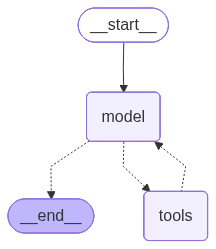

In [24]:
agent

#### 3.2.2.2 学习案例:温度单位转换

In [25]:
# from langchain.agents import create_agent # 最新 1.x 推荐入口
from pydantic import BaseModel, Field
from typing import Literal

# ======================
# 1. 环境变量
# ======================
# load_dotenv()
# API_KEY = os.getenv("API_KEY")
# BASE_URL = os.getenv("BASE_URL")

# llm = ChatOpenAI(
#     api_key=API_KEY,
#     base_url=BASE_URL,
#     model="deepseek-chat",
#     temperature=0.3,
# )

# ======================
# 2. 参数模型
# ======================
class TemperatureConvertInput(BaseModel):
    temperature: float = Field(description="需要转换的温度值，例如37.0")
    from_unit: str = Field(description="原始温度单位，只能是'celsius'（摄氏度）或'fahrenheit'（华氏度）")


# class TemperatureConvertInput(BaseModel):
#     temperature: float = Field(description="需要转换的温度值，例如37.0")
#     from_unit: Literal["celsius", "fahrenheit"] = Field(
#         description="原始温度单位，只能是 celsius 或 fahrenheit"
#     )  ## move all calibration to pydantic model, ensure input validity and simplify tool logic: suggested by codex

# ======================
# 3. 自定义工具
# ======================
@tool(args_schema=TemperatureConvertInput)
def temperature_converter(temperature: float, from_unit: str) -> str:
    """温度单位转换工具"""
    # """只支持摄氏度和华氏度之间的互相转换，不支持开尔文。"""
    if from_unit not in ["celsius", "fahrenheit"]:
        return f"错误：单位'{from_unit}'不合法，仅支持'celsius'或'fahrenheit'"
    
    if from_unit == "celsius":
        fahrenheit = temperature * 9/5 + 32
        return f"{temperature}摄氏度 = {fahrenheit:.2f}华氏度"
    else:
        celsius = (temperature - 32) * 5/9
        return f"{temperature}华氏度 = {celsius:.2f}摄氏度"

tools = [temperature_converter]

# ======================
# 4. Prompt模板（保留 agent_scratchpad）
# ======================
prompt = ChatPromptTemplate.from_messages([
    ("system",
     "你是一名专业温度转换助手，仅使用TemperatureConverter工具完成任务。"
     "严格校验参数，工具返回结果原样输出。"),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),  # 记录思考和工具调用
])

# ======================
# 5. 创建 Agent
# ======================
agent = create_agent(
    model=llm,
    tools=tools,
    debug=True,  # 👈 打开调试，显示模型调用过程
)


In [26]:

# ======================
# 6. 执行任务
# ======================
# if __name__ == "__main__":
    # 示例输入
query = "将237开尔文转换为华氏度"

# 调用 agent
response = agent.invoke({
    "messages": [{"role": "user", "content": query}]
})

# 输出最终回答
print("\n最终结果：")
print(response["messages"][-1].content)


[values] {'messages': [HumanMessage(content='将237开尔文转换为华氏度', additional_kwargs={}, response_metadata={}, id='9c1a9137-b8a1-43bb-a638-e2eadc0fa22c')]}
[updates] {'model': {'messages': [AIMessage(content='我需要先将开尔文转换为摄氏度，然后再转换为华氏度。\n\n开尔文转摄氏度的公式：°C = K - 273.15\n\n237K - 273.15 = -36.15°C\n\n现在将摄氏度转换为华氏度：', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 120, 'prompt_tokens': 335, 'total_tokens': 455, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}, 'prompt_cache_hit_tokens': 256, 'prompt_cache_miss_tokens': 79}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '65640790-a1c9-41a4-bbcb-4d60544c212c', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ee72a-0b5a-7630-b2de-ccf1e8dcd35c-0', tool_calls=[{'name': 'temperature_converter', 'args': {'temperature': -36.15, 'from_unit': 'celsius'}

#### 3.2.3.1 学习案例：创建文件

In [27]:
# from langchain.agents import create_agent
# from langchain_openai import ChatOpenAI
from langchain_community.agent_toolkits import FileManagementToolkit
# from dotenv import load_dotenv
# import os

# -------------------
# 1. 初始化环境
# -------------------
# load_dotenv()
# API_KEY = os.getenv("API_KEY")
# BASE_URL = os.getenv("BASE_URL")

# llm = ChatOpenAI(
#     api_key=API_KEY,
#     base_url=BASE_URL,
#     model="deepseek-chat",
#     temperature=0.3,
# )

# -------------------
# 2. 创建文件管理工具
# -------------------
toolkit = FileManagementToolkit(root_dir=".")
tools = toolkit.get_tools()

# -------------------
# 3. 创建 Agent（最新版）
# -------------------
agent = create_agent(
    model=llm,
    tools=tools,
    debug=True,  # 打开调试，显示模型思考和工具调用过程
)


C:\Users\wkqia\AppData\Local\Temp\ipykernel_37664\3538871960.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.agent_toolkits import FileManagementToolkit


In [28]:
tools

[CopyFileTool(root_dir='.'),
 DeleteFileTool(root_dir='.'),
 FileSearchTool(root_dir='.'),
 MoveFileTool(root_dir='.'),
 ReadFileTool(root_dir='.'),
 WriteFileTool(root_dir='.'),
 ListDirectoryTool(root_dir='.')]

In [29]:

# -------------------
# 4. 执行任务
# -------------------
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "请创建一个名为 llm诗词.txt 的文件，并在文件中写入一首原创七言绝句，主题围绕科技与人文的融合。"}
    ]
})

print("\n任务执行完成！文件已写入。")
print("Agent最终输出：\n", response["messages"][-1].content)


[values] {'messages': [HumanMessage(content='请创建一个名为 llm诗词.txt 的文件，并在文件中写入一首原创七言绝句，主题围绕科技与人文的融合。', additional_kwargs={}, response_metadata={}, id='14e7d653-c45b-4b91-afc8-231c260e6e0b')]}
[updates] {'model': {'messages': [AIMessage(content='好的，我来创建这个文件并写入一首原创七言绝句。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 798, 'total_tokens': 904, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 768}, 'prompt_cache_hit_tokens': 768, 'prompt_cache_miss_tokens': 30}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'f67ddf3b-65ec-42bf-866a-e71f2c30127c', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ee72a-18d2-7e72-ad4b-4b70cf7e8124-0', tool_calls=[{'name': 'write_file', 'args': {'file_path': 'llm诗词.txt', 'text': '《智韵》\n代码如诗织锦章，星河万里共流光。\n键盘敲落千秋月，屏幕生辉映古香。\n'}, 'id': 'call_00_

### 3.3.1 实践1：带记忆的对话机器人

In [ ]:
# from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
# from langchain_core.runnables.history import RunnableWithMessageHistory
# from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
# from langchain_openai import ChatOpenAI
# import contextlib
from langchain_experimental.tools import PythonREPLTool
import re
# from langchain.tools import tool
# import os
# from dotenv import load_dotenv

# -------------------------
# 1. 初始化环境与模型
# -------------------------
# load_dotenv()
# API_KEY = os.getenv("API_KEY")
# BASE_URL = os.getenv("BASE_URL")

# llm = ChatOpenAI(
#     api_key=API_KEY,
#     base_url=BASE_URL,
#     model="deepseek-chat",
#     temperature=0.3
# )

C:\Users\wkqia\AppData\Local\Temp\ipykernel_37664\253629903.py:7: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.tools import PythonREPLTool


In [31]:

calc_tool = PythonREPLTool()  # 数学计算工具
WINDOW_SIZE = 2  # 窗口记忆轮数

# -------------------------
# 2. 提示模板
# -------------------------
prompt = ChatPromptTemplate.from_messages([
    ("system", f"""
你是一名友好的个人助手，能记住最近{WINDOW_SIZE}轮对话。
如果用户问题包含数学计算，请先调用计算工具，再生成自然语言回答。
"""),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{input}")
])

# -------------------------
# 3. 工具调用逻辑
# -------------------------
def judge_and_calc(inputs):
    user_input = inputs["input"]
    
    calc_pattern = r"(\+|\-|\*|/|×|÷|=|计算|求和|求差|平方|立方|多少|等于)"
    if re.search(calc_pattern, user_input):
        # 提取表达式（简化版）
        expr = re.sub(r"[^\d\+\-\*\/\(\)\.]", "", user_input)
        calc_result = calc_tool.run(expr) if expr else "未识别到可计算的表达式"
        inputs["input"] = f"用户问题：{user_input}\n计算结果：{calc_result}\n请结合计算结果回答"
    return inputs

# -------------------------
# 4. 窗口记忆管理
# -------------------------
window_memory_store = {}

def get_window_session_history(session_id: str):
    if session_id not in window_memory_store:
        window_memory_store[session_id] = InMemoryChatMessageHistory()
    history = window_memory_store[session_id]
    # 保留最近N轮
    total = len(history.messages)
    if total > 2 * WINDOW_SIZE:
        history.messages = history.messages[-2 * WINDOW_SIZE:]
    return history


In [32]:

# -------------------------
# 5. 构建链
# -------------------------
chain = (
    RunnablePassthrough.assign(chat_history=lambda x: x.get("chat_history", []))
    | RunnableLambda(judge_and_calc)
    | prompt
    | llm
)

chain_with_memory = RunnableWithMessageHistory(
    runnable=chain,
    get_session_history=get_window_session_history,
    input_messages_key="input",
    history_messages_key="chat_history",
    output_messages_key="output"
)

# -------------------------
# 6. 预设对话列表（模拟用户输入）
# -------------------------
predefined_dialogues = [
    "你好，我今天想问一下37摄氏度是多少华氏度？",
    "如果把212华氏度转换成摄氏度是多少？",
    "帮我算一下 15 + 28 × 2",
    "谢谢你，今天的温度真热啊"
]

# -------------------------
# 7. 模拟多轮对话执行
# -------------------------

session_id = "student_001"
print("===== 窗口记忆数学助手（预设对话） =====\n")

for idx, user_input in enumerate(predefined_dialogues, 1):
    print(f"用户：{user_input}")
    
    response = chain_with_memory.invoke(
        {"input": user_input},
        config={"configurable": {"session_id": session_id}}
    )
    
    print(f"助手：{response.content}\n")


e:\OneDrive\Datawhale\AIagent\src\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
Python REPL can execute arbitrary code. Use with caution.


===== 窗口记忆数学助手（预设对话） =====

用户：你好，我今天想问一下37摄氏度是多少华氏度？
助手：你好！根据计算，37摄氏度等于 **98.6华氏度**。这是人体正常体温的常见换算值，希望这个回答对你有帮助！如果还有其他问题，随时问我哦~ 😊

用户：如果把212华氏度转换成摄氏度是多少？
助手：根据计算，212华氏度等于 **100摄氏度**。这是水的沸点温度（在标准大气压下），也是摄氏温标和华氏温标的一个关键对应点。如果还有其他问题，随时问我哦~ 😊

用户：帮我算一下 15 + 28 × 2
助手：根据计算，15 + 28 × 2 的结果是 **71**。  
（注意：按照数学运算顺序，先算乘法 28×2=56，再加 15 得到 71。）  
如果还有其他问题，随时问我哦~ 😊

用户：谢谢你，今天的温度真热啊
助手：不客气！天气热的时候记得多喝水、注意防晒哦～如果想知道当前温度对应的华氏度或摄氏度，或者需要其他帮助，随时告诉我！🌞😊



### 3.3.2 实践2：带记忆的文件夹操作助手

In [5]:
# =========================
# 1. 基础依赖
# =========================
import os
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.chat_history import InMemoryChatMessageHistory, BaseChatMessageHistory
from langchain_core.messages import AIMessage, ToolMessage

from langchain_core.messages import AIMessage, ToolMessage

# =========================
# 2. 模型
# =========================
load_dotenv()

llm = ChatOpenAI(
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
    model="deepseek-chat",
    temperature=0.3
)

# =========================
# 3. 记忆
# =========================
WINDOW_SIZE = 3
memory_store = {}

def get_session_history(session_id: str):
    if session_id not in memory_store:
        memory_store[session_id] = InMemoryChatMessageHistory()

    history = memory_store[session_id]

    if len(history.messages) > 2 * WINDOW_SIZE:
        history.messages = history.messages[-2 * WINDOW_SIZE:]

    return history

# =========================
# 4. 工具
# =========================
@tool
def list_files(path: str = ".") -> str:
    """查看指定目录下的文件列表"""
    try:
        if not os.path.exists(path):
            return f"路径不存在：{path}"

        items = os.listdir(path)
        if not items:
            return "目录为空"

        result = []
        for item in items:
            full = os.path.join(path, item)
            if os.path.isfile(full):
                result.append(f"文件：{item}（{os.path.getsize(full)} 字节）")
            else:
                result.append(f"文件夹：{item}")
        return "\n".join(result)
    except Exception as e:
        return f"查看失败：{e}"


@tool
def create_file(path: str, content: str = "") -> str:
    """创建文件，并可写入初始内容"""
    try:
        folder = os.path.dirname(path)
        if folder and not os.path.exists(folder):
            os.makedirs(folder)

        with open(path, "w", encoding="utf-8") as f:
            f.write(content)

        return f"文件已创建：{path}"
    except Exception as e:
        return f"创建失败：{e}"
    
@tool
def write_file(path: str, content: str, append: bool = True) -> str:
    """向文件写入内容，支持追加或覆盖"""
    try:
        if not os.path.exists(path):
            return f"文件不存在：{path}"

        mode = "a" if append else "w"
        with open(path, mode, encoding="utf-8") as f:
            f.write(content)

        return f"写入成功（{'追加' if append else '覆盖'}）"
    except Exception as e:
        return f"写入失败：{e}"
    
@tool
def delete_file(path: str) -> str:
    """删除文件或空文件夹"""
    try:
        if not os.path.exists(path):
            return f"路径不存在：{path}"

        if os.path.isfile(path):
            os.remove(path)
            return f"文件已删除：{path}"

        if os.path.isdir(path):
            if os.listdir(path):
                return "文件夹非空，无法删除"
            os.rmdir(path)
            return f"文件夹已删除：{path}"

        return "无效路径"
    except Exception as e:
        return f"删除失败：{e}"

tools = [list_files, create_file, write_file, delete_file]

# =========================
# 5. 创建 Agent
# =========================

prompt = ChatPromptTemplate.from_messages([
    ("system",
     "你是一个文件操作智能助手。"
     "当用户请求涉及文件或目录操作时，你可以自主决定是否调用工具。"
     "如果不需要工具，直接回答用户。"),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{input}")
])
# =========================
# 6. 构建 Tool-Calling Agent
# =========================
agent = prompt | llm.bind_tools(tools)

agent_with_memory = RunnableWithMessageHistory(
    runnable=agent,
    get_session_history=get_session_history,
    input_messages_key="input",
    history_messages_key="chat_history"
)


if __name__ == "__main__":
    session_id = "tool_agent_demo"

    print("===== 🧠 Tool Calling 文件 Agent =====")
    print("示例：")
    print(" - 查看当前文件夹")
    print(" - 创建文件 test.txt 内容 Hello")
    print(" - 写入文件 test.txt 内容 World 追加")
    print(" - 删除文件 test.txt")
    print("输入 q 退出\n")

    while True:
        user_input = input("你：")
        if user_input.lower() in ["q", "quit", "退出"]:
            print("助手：再见 👋")
            break

        # ===== 第一次：模型思考 =====
        result = agent_with_memory.invoke(
            {"input": user_input},
            config={"configurable": {"session_id": session_id}}
        )

        history = get_session_history(session_id)

        print("\n🧠【模型输出】")
        if result.content:
            print(result.content)

        # ===== 模型决定调用工具 =====
        if isinstance(result, AIMessage) and result.tool_calls:
            print("\n🔧【模型决定调用工具】")
            for call in result.tool_calls:
                tool_name = call["name"]
                tool_args = call["args"]

                print(f"➡️ 工具名：{tool_name}")
                print(f"➡️ 参数：{tool_args}")

                tool_func = next(t for t in tools if t.name == tool_name)
                observation = tool_func.invoke(tool_args)

                print("\n📦【工具执行结果】")
                print(observation)

                history.add_message(
                    ToolMessage(
                        tool_call_id=call["id"],
                        content=str(observation)
                    )
                )

            print("\n✅【本轮结束：工具执行完成】\n")
            continue  # 回到 while True 等用户输入

        # ===== 最终回答（没有工具调用） =====
        print("\n✅【最终回答】")
        print(result.content, "\n")

===== 🧠 Tool Calling 文件 Agent =====
示例：
 - 查看当前文件夹
 - 创建文件 test.txt 内容 Hello
 - 写入文件 test.txt 内容 World 追加
 - 删除文件 test.txt
输入 q 退出



e:\OneDrive\Datawhale\AIagent\src\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)



🧠【模型输出】
你好！我是一个文件操作智能助手，可以帮你处理各种文件和目录相关的操作，比如：

- **查看文件列表** - 列出指定目录下的文件和文件夹
- **创建文件** - 新建文件并写入初始内容
- **写入内容** - 向已有文件写入或追加内容
- **删除文件/空文件夹** - 删除指定的文件或空目录

如果你有文件或目录方面的需求，随时告诉我，我会尽力帮你完成！😊

✅【最终回答】
你好！我是一个文件操作智能助手，可以帮你处理各种文件和目录相关的操作，比如：

- **查看文件列表** - 列出指定目录下的文件和文件夹
- **创建文件** - 新建文件并写入初始内容
- **写入内容** - 向已有文件写入或追加内容
- **删除文件/空文件夹** - 删除指定的文件或空目录

如果你有文件或目录方面的需求，随时告诉我，我会尽力帮你完成！😊 


🧠【模型输出】
好的，我来查看当前文件夹的内容。

🔧【模型决定调用工具】
➡️ 工具名：list_files
➡️ 参数：{'path': '.'}

📦【工具执行结果】
文件：api_test.ipynb（1797 字节）
文件：chapter1_demo.ipynb（5536 字节）
文件：chapter2.ipynb（41919 字节）
文件：chapter3.ipynb（103940 字节）
文件：learning_method_examples.json（808 字节）
文件：llm诗词.txt（114 字节）
文件：test.txt（0 字节）

✅【本轮结束：工具执行完成】


🧠【模型输出】
我是你的文件操作智能助手！😊

刚才我已经查看了当前文件夹的内容，里面包含以下文件：

| 文件名 | 大小 |
|--------|------|
| `api_test.ipynb` | 1.8 KB |
| `chapter1_demo.ipynb` | 5.4 KB |
| `chapter2.ipynb` | 41.9 KB |
| `chapter3.ipynb` | 103.9 KB |
| `learning_method_examples.json` | 808 字节 |
| `llm诗词.txt` | 114 字节 |
| `test.txt` | 0 字节 |

你可以随时让